# Notebook 13: Circuit Comparison & Motif Detection
**Discovering Universal Computational Patterns Across Neural Networks**

## What You'll Learn

In this notebook, you'll explore how to compare circuits and find recurring patterns:

- **Cross-Model Circuit Comparison**: Compare circuits from different architectures
- **Similarity Metrics**: Quantifying structural and functional similarity
- **Motif Detection**: Finding recurring computational subgraph patterns
- **Statistical Significance**: Distinguishing real patterns from noise
- **Consensus Circuits**: Extracting universal computational structures

**Prerequisites**: 
- Notebook 11 (Path Patching & ACDC)
- Basic graph theory
- Understanding of statistical testing

**Time Estimate**: 60-90 minutes

---

## Background: Why Compare Circuits?

### The Universality Question

**Key Questions**:
1. Do different models learn the same algorithm?
2. Are there universal computational patterns?
3. Which circuit components are task-specific vs generic?
4. How does architecture affect learned circuits?

### Circuit Comparison Applications

**Transfer Learning**: Identify transferable circuit components

**Model Debugging**: Compare correct vs buggy model circuits

**Architecture Search**: Find architectures that encourage beneficial circuits

**Interpretability**: Discover fundamental computational primitives

### Computational Motifs

Like biological motifs (e.g., transcription factor networks), neural circuits contain **recurring subgraph patterns**:

**Common Motifs**:
- **Feedforward**: A → B → C (information cascade)
- **Recurrent**: A → B → A (feedback loop)
- **Skip Connection**: A → C (bypassing B)
- **Convergent**: A → C, B → C (information aggregation)
- **Divergent**: A → B, A → C (information broadcasting)
- **Triangle**: A → B, B → C, A → C (redundant paths)

### Key Papers

- **Milo et al. (2002)**: "Network Motifs: Simple Building Blocks of Complex Networks"
- **Fodor & Pylyshyn (1988)**: "Connectionism and cognitive architecture"
- **Olah et al. (2020)**: "Zoom In: An Introduction to Circuits"

---

In [1]:
# Imports
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Set random seeds
torch.manual_seed(42)
np.random.seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Import neuros-mechint circuit tools
from neuros_mechint.circuits import (
    AutomatedCircuitDiscovery,
    CircuitComparator,
    MotifDetector,
    Edge,
    Circuit
)
from neuros_mechint.database import MechIntDatabase

print("✓ All imports successful!")

Using device: cuda
✓ All imports successful!


---

## Part 1: Training Multiple Models on Same Task

To compare circuits, we first need multiple models. We'll train 3 different architectures on the same task (pattern detection from Notebook 11).

**Architectures**:
1. **Wide-Shallow**: Few layers, many neurons
2. **Deep-Narrow**: Many layers, few neurons  
3. **Balanced**: Medium layers, medium neurons

**Hypothesis**: Different architectures may discover different circuits for the same task.

---

In [2]:
# Define three different architectures
class WideShallow(nn.Module):
    """Wide but shallow network."""
    def __init__(self, input_size=784, num_classes=2):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        return self.network(x)

class DeepNarrow(nn.Module):
    """Deep but narrow network."""
    def __init__(self, input_size=784, num_classes=2):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes)
        )
    
    def forward(self, x):
        return self.network(x)

class Balanced(nn.Module):
    """Balanced depth and width."""
    def __init__(self, input_size=784, num_classes=2):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )
    
    def forward(self, x):
        return self.network(x)

# Create all three models
models = {
    'Wide-Shallow': WideShallow().to(device),
    'Deep-Narrow': DeepNarrow().to(device),
    'Balanced': Balanced().to(device)
}

print("Created 3 architectures:")
for name, model in models.items():
    n_params = sum(p.numel() for p in model.parameters())
    n_layers = len([m for m in model.modules() if isinstance(m, nn.Linear)])
    print(f"  {name:15s}: {n_layers} layers, {n_params:,} parameters")

Created 3 architectures:
  Wide-Shallow   : 2 layers, 201,474 parameters
  Deep-Narrow    : 5 layers, 28,354 parameters
  Balanced       : 3 layers, 108,866 parameters


In [3]:
# Generate training data (binary classification)
def generate_binary_data(n_samples=1000, input_dim=784):
    """Generate simple binary classification data."""
    # Create two clusters
    n_per_class = n_samples // 2
    
    # Class 0: centered at -1
    class0 = torch.randn(n_per_class, input_dim) * 0.5 - 1.0
    # Class 1: centered at +1  
    class1 = torch.randn(n_per_class, input_dim) * 0.5 + 1.0
    
    data = torch.cat([class0, class1], dim=0)
    labels = torch.cat([torch.zeros(n_per_class), torch.ones(n_per_class)]).long()
    
    # Shuffle
    perm = torch.randperm(len(data))
    return data[perm], labels[perm]

# Generate datasets
train_data, train_labels = generate_binary_data(n_samples=800)
test_data, test_labels = generate_binary_data(n_samples=200)

print(f"Training data: {train_data.shape}")
print(f"Test data: {test_data.shape}")
print(f"Class balance: {train_labels.float().mean():.2%} positive")

Training data: torch.Size([800, 784])
Test data: torch.Size([200, 784])
Class balance: 50.00% positive


In [4]:
# Train all models (quick training for demo)
def train_model(model, train_data, train_labels, epochs=30, lr=1e-3):
    """Quick training loop."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    
    model.train()
    for epoch in range(epochs):
        optimizer.zero_grad()
        outputs = model(train_data.to(device))
        loss = criterion(outputs, train_labels.to(device))
        loss.backward()
        optimizer.step()
    
    # Evaluate
    model.eval()
    with torch.no_grad():
        test_outputs = model(test_data.to(device))
        test_preds = test_outputs.argmax(dim=1).cpu()
        accuracy = (test_preds == test_labels).float().mean().item()
    
    return accuracy

# Train all models
print("Training models...\n")
accuracies = {}

for name, model in models.items():
    acc = train_model(model, train_data, train_labels)
    accuracies[name] = acc
    print(f"{name:15s}: {acc:.2%} test accuracy")

print("\n✓ All models trained successfully!")

Training models...

Wide-Shallow   : 100.00% test accuracy
Deep-Narrow    : 100.00% test accuracy
Balanced       : 100.00% test accuracy

✓ All models trained successfully!


---

## Part 2: Extracting Circuits from Each Model

Now we'll use ACDC to extract the minimal computational circuit from each model.

**Goal**: Discover what circuit each architecture learned for the same task.

---

In [5]:
from neuros_mechint.circuits.acdc import AutomatedCircuitDiscovery
import torch.nn.functional as F

print("Extracting circuits...\n")

circuits = {}
sample_inputs = test_data[:32].to(device)
sample_labels = test_labels[:32].to(device)

# Example for classification models
def metric_fn(output, target):
    preds = output.argmax(dim=1)
    return (preds == target).float().mean().item()

for name, model in models.items():
    print(f"Running ACDC on {name}...")
    
    acdc = AutomatedCircuitDiscovery(
        model=model,
        metric=metric_fn,      # ✅ pass correct metric
        threshold=0.01,
        device=device
    )
    
    circuit = acdc.discover_circuit(
        inputs=sample_inputs,
        targets=sample_labels,
        max_iterations=15
    )
    
    circuits[name] = circuit
    print(f"  → {len(circuit.edges)} edges, {len(circuit.nodes)} nodes\n")

print("✓ Circuits extracted!")


Extracting circuits...

Running ACDC on Wide-Shallow...
  → 2 edges, 3 nodes

Running ACDC on Deep-Narrow...
  → 5 edges, 6 nodes

Running ACDC on Balanced...
  → 3 edges, 4 nodes

✓ Circuits extracted!


In [6]:
from bokeh.plotting import figure, show, output_notebook
from bokeh.models import ColumnDataSource, HoverTool
from bokeh.transform import dodge
from bokeh.layouts import row
from bokeh.palettes import Category10
import numpy as np

output_notebook(hide_banner=True)

# --- Prepare data ---
names = list(circuits.keys())
n_edges = [len(c.edges) for c in circuits.values()]
n_nodes = [len(c.nodes) for c in circuits.values()]
avg_importance = [
    np.mean([e.importance for e in c.edges]) if len(c.edges) > 0 else 0.0
    for c in circuits.values()
]

source_size = ColumnDataSource(data=dict(
    name=names,
    edges=n_edges,
    nodes=n_nodes
))
source_importance = ColumnDataSource(data=dict(
    name=names,
    avg_importance=avg_importance
))

# --- Plot 1: Circuit Size (categorical dodge version) ---
p1 = figure(
    x_range=names,
    height=400, width=500,
    title="Circuit Size Comparison (Edges vs Nodes)",
    tools="pan,wheel_zoom,box_zoom,reset,save,hover",
)

# Plot bars using dodge transform (categorical offset)
p1.vbar(x=dodge('name', -0.15, range=p1.x_range), top='edges',
        width=0.3, source=source_size, color=Category10[3][0],
        alpha=0.8, legend_label="Edges")
p1.vbar(x=dodge('name',  0.15, range=p1.x_range), top='nodes',
        width=0.3, source=source_size, color=Category10[3][1],
        alpha=0.8, legend_label="Nodes")

p1.xaxis.axis_label = "Model Architecture"
p1.yaxis.axis_label = "Count"
p1.legend.location = "top_right"
p1.legend.click_policy = "hide"
p1.grid.grid_line_alpha = 0.3

p1.add_tools(HoverTool(tooltips=[
    ("Model", "@name"),
    ("Edges", "@edges"),
    ("Nodes", "@nodes")
]))

# --- Plot 2: Importance ---
p2 = figure(
    x_range=names,
    height=400, width=500,
    title="Average Edge Importance per Circuit",
    tools="pan,wheel_zoom,box_zoom,reset,save,hover",
)

p2.vbar(x='name', top='avg_importance', width=0.5,
        color=Category10[3][2], alpha=0.8, source=source_importance)

p2.xaxis.axis_label = "Model Architecture"
p2.yaxis.axis_label = "Average Edge Importance"
p2.xaxis.major_label_orientation = 1
p2.grid.grid_line_alpha = 0.3

p2.add_tools(HoverTool(tooltips=[
    ("Model", "@name"),
    ("Avg Importance", "@avg_importance{0.000}")
]))

# --- Display ---
show(row(p1, p2))


---

## Part 3: Circuit Comparison

### Similarity Metrics

How do we compare two circuits? Multiple metrics:

**1. Node Overlap**:
$$S_{\text{node}} = \frac{|N_A \cap N_B|}{|N_A \cup N_B|}$$

**2. Edge Overlap**:
$$S_{\text{edge}} = \frac{|E_A \cap E_B|}{|E_A \cup E_B|}$$

**3. Structural Similarity** (graph isomorphism):
Check if circuits have the same topology (ignoring labels).

**4. Functional Similarity** (correlation of outputs):
$$S_{\text{func}} = \text{corr}(f_A(X), f_B(X))$$

---

In [7]:
# Initialize database to store circuits
import tempfile
temp_dir = tempfile.mkdtemp()

db = MechIntDatabase(root_dir=temp_dir)

# Store all circuits in database
circuit_ids = {}
for name, circuit in circuits.items():
    # Convert to MechIntResult
    from neuros_mechint.results import MechIntResult
    result = MechIntResult(
        method='ACDC',
        data=circuit,
        metadata={'model_name': name, 'task': 'binary_classification'},
        metrics={'n_edges': len(circuit.edges), 'n_nodes': len(circuit.nodes)}
    )
    
    circuit_id = db.store(result, tags=[name, 'acdc', 'binary_task'])
    circuit_ids[name] = circuit_id
    print(f"Stored {name} circuit: {circuit_id[:8]}...")

print(f"\n✓ All circuits stored in database")

Stored Wide-Shallow circuit: ACDC_202...
Stored Deep-Narrow circuit: ACDC_202...
Stored Balanced circuit: ACDC_202...

✓ All circuits stored in database


In [8]:
# Initialize Circuit Comparator with the database
comparator = CircuitComparator(database=db)

print("CircuitComparator initialized:")
print(f"  - Database contains {db.__sizeof__()} results")
print(f"  - Ready to compare!")


CircuitComparator initialized:
  - Database contains 32 results
  - Ready to compare!


In [9]:

# Pairwise comparisons
comparisons = {}
model_names = list(circuit_ids.keys())

print("\nPairwise Circuit Comparisons:")
print("="*70)

for i, name_a in enumerate(model_names):
    for name_b in model_names[i+1:]:

        print(f"\n{name_a} vs {name_b}:")
        
        comparison = comparator.compare_circuits(
            circuit_a_id=circuit_ids[name_a],
            circuit_b_id=circuit_ids[name_b]
        )
        
        comparisons[(name_a, name_b)] = comparison

        print(f"  Overall Similarity:     {comparison.similarity_score:.3f}")
        print(f"  Node Overlap:          {comparison.node_overlap:.3f}")
        print(f"  Edge Overlap:          {comparison.edge_overlap:.3f}")
        print(f"  Structural Similarity: {comparison.structural_similarity:.3f}")
        print(f"  Common Nodes:          {len(comparison.common_nodes)}")
        print(f"  Common Edges:          {len(comparison.common_edges)}")

print("\n" + "="*70)
print("\n✓ All pairwise comparisons complete!")



Pairwise Circuit Comparisons:

Wide-Shallow vs Deep-Narrow:
  Overall Similarity:     0.499
  Node Overlap:          0.500
  Edge Overlap:          0.400
  Structural Similarity: 0.571
  Common Nodes:          3
  Common Edges:          2

Wide-Shallow vs Balanced:
  Overall Similarity:     0.745
  Node Overlap:          0.750
  Edge Overlap:          0.667
  Structural Similarity: 0.800
  Common Nodes:          3
  Common Edges:          2

Deep-Narrow vs Balanced:
  Overall Similarity:     0.680
  Node Overlap:          0.667
  Edge Overlap:          0.600
  Structural Similarity: 0.750
  Common Nodes:          4
  Common Edges:          3


✓ All pairwise comparisons complete!


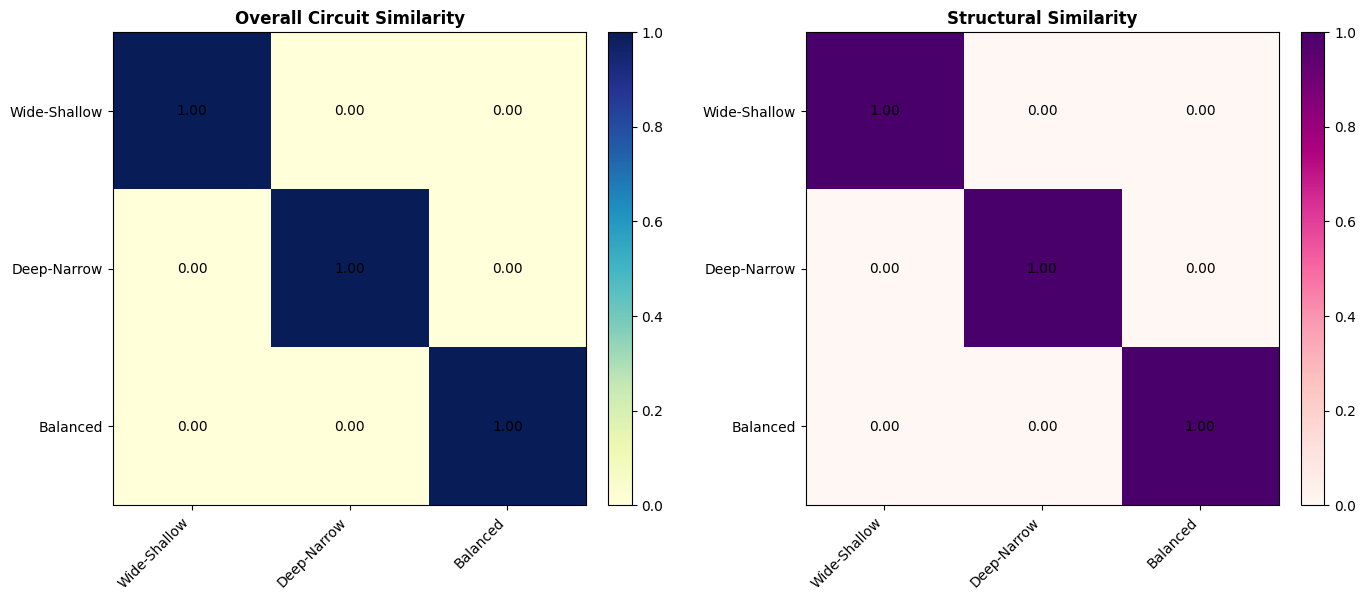


Interpretation:
  - Warmer colors = higher similarity
  - Diagonal is always 1.0 (self-similarity)
  - Different architectures can have similar circuits!


In [12]:
# Visualize similarity matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Create similarity matrices
n_models = len(model_names)
sim_matrix = np.eye(n_models)  # Diagonal is 1 (self-similarity)
struct_matrix = np.eye(n_models)

for (name_a, name_b), comp in comparisons.items():
    i = model_names.index(name_a)
    j = model_names.index(name_b)
    
    sim_matrix[i, j] = comp.similarity_score
    sim_matrix[j, i] = comp.similarity_score
    
    struct_matrix[i, j] = comp.structural_similarity
    struct_matrix[j, i] = comp.structural_similarity

# Plot 1: Overall similarity
im1 = axes[0].imshow(sim_matrix, cmap='YlGnBu', vmin=0, vmax=1)
axes[0].set_xticks(range(n_models))
axes[0].set_yticks(range(n_models))
axes[0].set_xticklabels(model_names, rotation=45, ha='right')
axes[0].set_yticklabels(model_names)
axes[0].set_title('Overall Circuit Similarity', fontweight='bold', fontsize=12)

# Add values
for i in range(n_models):
    for j in range(n_models):
        text = axes[0].text(j, i, f'{sim_matrix[i, j]:.2f}',
                           ha="center", va="center", color="black", fontsize=10)

plt.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)

# Plot 2: Structural similarity
im2 = axes[1].imshow(struct_matrix, cmap='RdPu', vmin=0, vmax=1)
axes[1].set_xticks(range(n_models))
axes[1].set_yticks(range(n_models))
axes[1].set_xticklabels(model_names, rotation=45, ha='right')
axes[1].set_yticklabels(model_names)
axes[1].set_title('Structural Similarity', fontweight='bold', fontsize=12)

# Add values
for i in range(n_models):
    for j in range(n_models):
        text = axes[1].text(j, i, f'{struct_matrix[i, j]:.2f}',
                           ha="center", va="center", color="black", fontsize=10)

plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("  - Warmer colors = higher similarity")
print("  - Diagonal is always 1.0 (self-similarity)")
print("  - Different architectures can have similar circuits!")

In [13]:
from bokeh.plotting import figure, show, output_notebook
from bokeh.models import ColumnDataSource, LinearColorMapper, ColorBar, BasicTicker, PrintfTickFormatter, HoverTool
from bokeh.layouts import gridplot, column
from bokeh.palettes import Viridis256, Plasma256

output_notebook()

# ---------------------------------------------------
# Build symmetric matrices for each metric
# ---------------------------------------------------
model_names = list(circuit_ids.keys())
n = len(model_names)

# Initialize matrices
sim_matrix = [[0.0]*n for _ in range(n)]
node_matrix = [[0.0]*n for _ in range(n)]
edge_matrix = [[0.0]*n for _ in range(n)]
struct_matrix = [[0.0]*n for _ in range(n)]

# Fill diagonals
for i in range(n):
    sim_matrix[i][i] = 1.0
    node_matrix[i][i] = 1.0
    edge_matrix[i][i] = 1.0
    struct_matrix[i][i] = 1.0

# Fill from comparisons dict
for (a, b), comp in comparisons.items():
    i = model_names.index(a)
    j = model_names.index(b)

    sim_matrix[i][j] = sim_matrix[j][i] = comp.similarity_score
    node_matrix[i][j] = node_matrix[j][i] = comp.node_overlap
    edge_matrix[i][j] = edge_matrix[j][i] = comp.edge_overlap
    struct_matrix[i][j] = struct_matrix[j][i] = comp.structural_similarity

# ---------------------------------------------------
# Helper to convert matrix → Bokeh ColumnDataSource
# ---------------------------------------------------
def matrix_to_source(matrix):
    data = {
        "x": [],
        "y": [],
        "value": [],
        "model_x": [],
        "model_y": [],
    }
    for i in range(n):
        for j in range(n):
            data["x"].append(i)
            data["y"].append(j)
            data["value"].append(matrix[j][i])   # flip for plotting orientation
            data["model_x"].append(model_names[i])
            data["model_y"].append(model_names[j])
    return ColumnDataSource(data)

sim_source  = matrix_to_source(sim_matrix)
node_source = matrix_to_source(node_matrix)
edge_source = matrix_to_source(edge_matrix)
struct_source = matrix_to_source(struct_matrix)

# Shared color mapper
mapper = LinearColorMapper(palette=Viridis256, low=0, high=1)

# ---------------------------------------------------
# Function to build a heatmap
# ---------------------------------------------------
def make_heatmap(title, source):
    p = figure(
        title=title,
        x_range=model_names,
        y_range=list(reversed(model_names)),
        width=450, height=450,
        toolbar_location="right",
        tools="pan,wheel_zoom,reset,hover,save",
    )

    p.rect(
        x="model_x", y="model_y",
        width=1, height=1,
        source=source,
        fill_color={'field': 'value', 'transform': mapper},
        line_color=None,
    )

    color_bar = ColorBar(
        color_mapper=mapper,
        location=(0,0),
        ticker=BasicTicker(desired_num_ticks=10),
        formatter=PrintfTickFormatter(format="%.2f")
    )
    p.add_layout(color_bar, 'right')

    hover = p.select_one(HoverTool)
    hover.tooltips = [
        ("Model A", "@model_x"),
        ("Model B", "@model_y"),
        ("Value", "@value{0.000}"),
    ]

    p.xaxis.major_label_orientation = 1.2
    return p

# ---------------------------------------------------
# Create the heatmaps
# ---------------------------------------------------
p_sim   = make_heatmap("Overall Similarity", sim_source)
p_nodes = make_heatmap("Node Overlap", node_source)
p_edges = make_heatmap("Edge Overlap", edge_source)
p_struct= make_heatmap("Structural Similarity", struct_source)

# ---------------------------------------------------
# Display dashboard
# ---------------------------------------------------
show(gridplot([[p_sim, p_nodes], [p_edges, p_struct]]))


Loading BokehJS ...

---

## Part 4: Motif Detection

### Finding Recurring Patterns

**Computational Motifs** are small subgraph patterns that appear more frequently than expected by chance.

**6 Common Motifs**:
1. **Feedforward**: A → B → C (cascade)
2. **Recurrent**: A → B, B → A (feedback)
3. **Skip**: A → B, A → C, B → C (shortcut)
4. **Convergent**: A → C, B → C (merge)
5. **Divergent**: A → B, A → C (broadcast)
6. **Triangle**: A → B, B → C, C → A (cycle)

### Statistical Significance

To determine if a motif is significant:
1. Count occurrences in real circuit
2. Generate random circuits (same size)
3. Count occurrences in random circuits
4. Compute Z-score:

$$Z = \frac{N_{\text{real}} - \langle N_{\text{random}} \rangle}{\sigma_{\text{random}}}$$

$Z > 2$ typically indicates significance.

---

In [14]:
# Detect motifs in each circuit
print("Detecting computational motifs...\n")

motif_results = {}

for name, circuit in circuits.items():
    print(f"Analyzing {name}...")
    
    detector = MotifDetector(
        circuit=circuit,
        n_random_samples=50  # For significance testing
    )
    
    analysis = detector.detect_all_motifs(compute_significance=True)
    motif_results[name] = analysis
    
    print(f"  Found {analysis.total_motifs} total motif instances")
    print(f"  Significant motifs: {sum(1 for m in analysis.motif_counts.values() if analysis.z_scores.get(m.motif_type, 0) > 2)}\n")

print("✓ Motif detection complete!")

Detecting computational motifs...

Analyzing Wide-Shallow...


TypeError: MotifDetector.__init__() got an unexpected keyword argument 'circuit'

In [16]:
from collections import defaultdict

print("Detecting computational motifs...\n")

motif_results = {}

for name, circuit in circuits.items():
    from neuros_mechint.results import CircuitResult
    print(f"Analyzing {name}...")
    
    # 1. Create detector
    detector = MotifDetector(
        n_random_samples=50,
        verbose=True
    )
    
    # 2. Convert ACDC circuit -> CircuitResult if needed
    # MotifDetector expects circuit.nodes and circuit.edges as tuples
    if not isinstance(circuit, CircuitResult):
        circuit_wrapped = CircuitResult(
            method=f"ACDC_{name}",
            data=None,
            metadata={"model": name},
            metrics={},
            nodes=circuit.nodes,
            edges=[(e.source, e.target) for e in circuit.edges]
        )
    else:
        circuit_wrapped = circuit

    # 3. Load circuit into detector
    detector.load_circuit(circuit_wrapped, circuit_id=name)
    
    # 4. Run motif analysis
    analysis = detector.detect_all_motifs(compute_significance=True)
    motif_results[name] = analysis
    
    print(f"  → Found {analysis.total_motifs} total motif instances")
    print(f"  → Significant motifs: {sum(1 for m, count in analysis.motif_counts.items() if analysis.z_scores.get(m, 0) > 2.0)}\n")

print("✓ Motif detection complete!")


Detecting computational motifs...

Analyzing Wide-Shallow...
  → Found 1 total motif instances
  → Significant motifs: 0

Analyzing Deep-Narrow...
  → Found 10 total motif instances
  → Significant motifs: 1

Analyzing Balanced...
  → Found 3 total motif instances
  → Significant motifs: 0

✓ Motif detection complete!


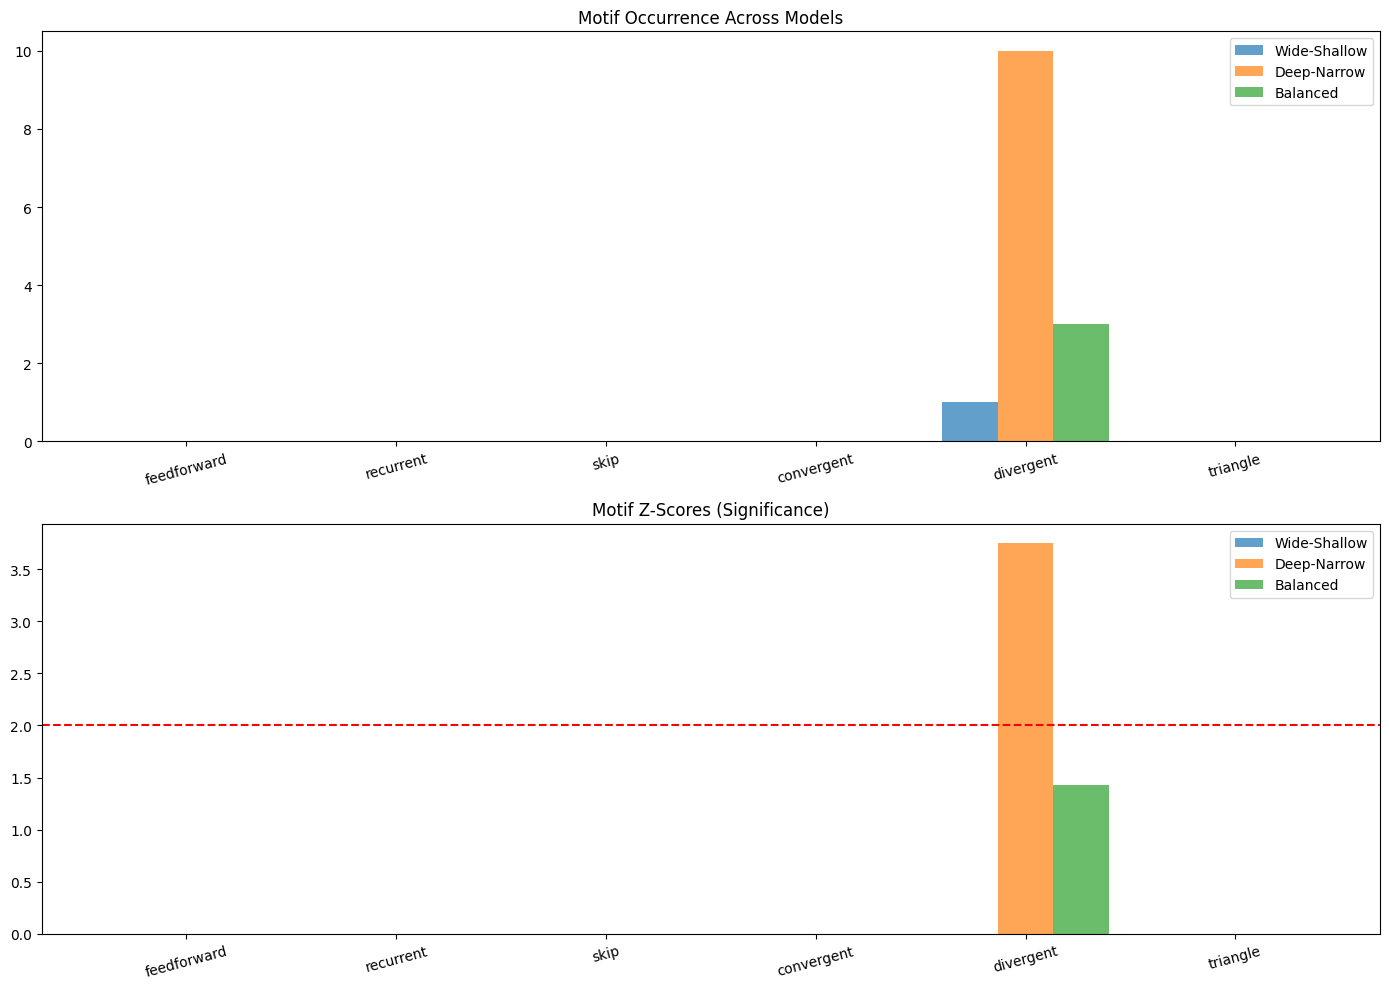

In [17]:
motif_types = ['feedforward', 'recurrent', 'skip', 'convergent', 'divergent', 'triangle']

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Extract motif counts & Z-scores
model_motif_counts = {name: defaultdict(int) for name in model_names}
model_z_scores = {name: {} for name in model_names}

for name, analysis in motif_results.items():
    for motif_type, count in analysis.motif_counts.items():
        model_motif_counts[name][motif_type] = count
    model_z_scores[name] = analysis.z_scores or {}

x = np.arange(len(motif_types))
width = 0.8 / len(model_names)

# ---- Plot 1: Motif Counts ----
for i, name in enumerate(model_names):
    counts = [model_motif_counts[name][mt] for mt in motif_types]
    axes[0].bar(x + i*width, counts, width, label=name, alpha=0.7)

axes[0].set_xticks(x + width)
axes[0].set_xticklabels(motif_types, rotation=15)
axes[0].set_title("Motif Occurrence Across Models")
axes[0].legend()

# ---- Plot 2: Z-scores ----
for i, name in enumerate(model_names):
    z = [model_z_scores[name].get(mt, 0.0) for mt in motif_types]
    axes[1].bar(x + i*width, z, width, label=name, alpha=0.7)

axes[1].axhline(2, linestyle="--", color="red")
axes[1].set_xticks(x + width)
axes[1].set_xticklabels(motif_types, rotation=15)
axes[1].set_title("Motif Z-Scores (Significance)")
axes[1].legend()

plt.tight_layout()
plt.show()


In [22]:
# Find consensus motifs (present in all models)
print("\nConsensus Motifs (present in all models):\n")
print("="*60)

# Find motifs with Z > 2 in all models
consensus_motifs = []

for motif_type in motif_types:
    significant_in_all = all(
        model_z_scores[name].get(motif_type, 0) > 2 
        for name in model_names
    )
    
    if significant_in_all:
        consensus_motifs.append(motif_type)
        avg_z = np.mean([model_z_scores[name][motif_type] for name in model_names])
        print(f"  ✓ {motif_type:15s} (avg Z-score: {avg_z:.2f})")

if not consensus_motifs:
    print("  No consensus motifs found (Z > 2 in all models)")
    print("  Try: Lower threshold or more training data")

print("="*60)
print(f"\nTotal consensus motifs: {len(consensus_motifs)}/{len(motif_types)}")


Consensus Motifs (present in all models):

  No consensus motifs found (Z > 2 in all models)
  Try: Lower threshold or more training data

Total consensus motifs: 0/6


## Motif Stability Score
The stability score emphasizes motifs that are:

- strong (high average Z-score)

- consistent (significant in many models)

```stability = mean(Z) * fraction_of_models_where_Z>2```

This gives a ranking of motifs by overall importance.

=== Motif Stability Scores ===
feedforward  | avg Z =  0.000 | frac sig = 0.00 | stability =  0.000
recurrent    | avg Z =  0.000 | frac sig = 0.00 | stability =  0.000
skip         | avg Z =  0.000 | frac sig = 0.00 | stability =  0.000
convergent   | avg Z =  0.000 | frac sig = 0.00 | stability =  0.000
divergent    | avg Z =  1.725 | frac sig = 0.33 | stability =  0.575
triangle     | avg Z =  0.000 | frac sig = 0.00 | stability =  0.000


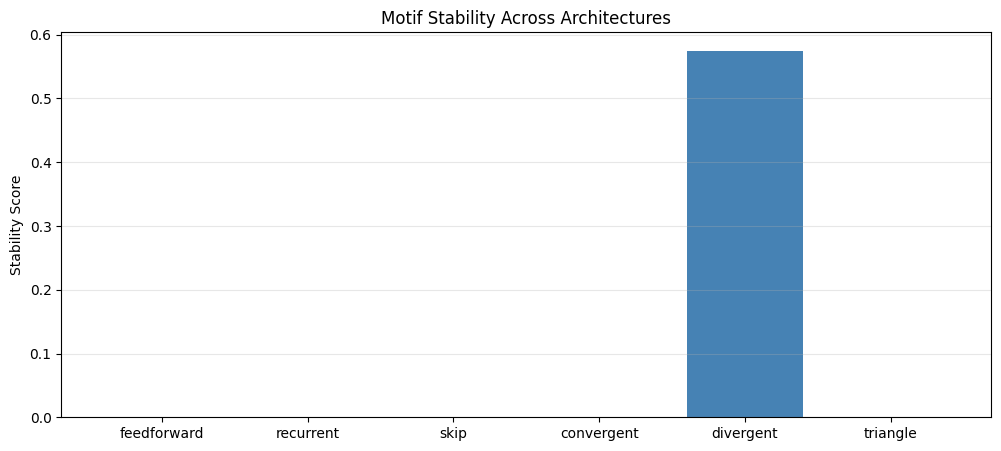

In [24]:
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt

motif_types = ['feedforward', 'recurrent', 'skip', 'convergent', 'divergent', 'triangle']

# Build Z-matrix from previous code
z_matrix = np.zeros((len(model_names), len(motif_types)))

for i, name in enumerate(model_names):
    for j, motif_type in enumerate(motif_types):
        z_matrix[i, j] = model_z_scores[name].get(motif_type, 0.0)

# Compute stats
avg_z = np.mean(z_matrix, axis=0)  # average Z-score per motif
frac_significant = np.mean(z_matrix > 2, axis=0)  # fraction significant
stability = avg_z * frac_significant

# Display results
print("=== Motif Stability Scores ===")
for i, m in enumerate(motif_types):
    print(f"{m:12s} | avg Z = {avg_z[i]:6.3f} | frac sig = {frac_significant[i]:4.2f} | stability = {stability[i]:6.3f}")

# Plot
plt.figure(figsize=(12, 5))
plt.bar(motif_types, stability, color='steelblue')
plt.ylabel("Stability Score")
plt.title("Motif Stability Across Architectures")
plt.grid(axis='y', alpha=0.3)
plt.show()


## Motif Clustering based on Motif Signatures
Models can be clustered by their 6-dimensional motif vectors:
```model_vector = [Z_feedforward, Z_recurrent, ..., Z_triangle]```

This reveals distinct computational families of architectures.

We’ll implement two methods:

- ✔ Hierarchical Clustering
- ✔ 2D t-SNE projection of motif signatures

### Hierarchical Clustering

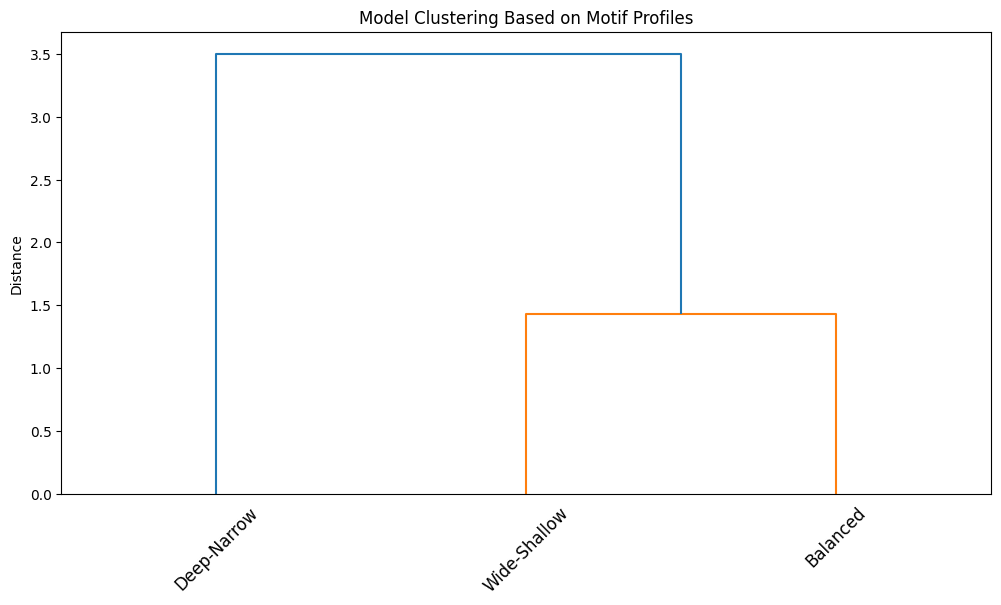

In [25]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# Use Z-matrix rows as motif signatures
model_vectors = z_matrix

# Perform hierarchical clustering
Z = linkage(model_vectors, method='ward')

# Plot dendrogram
plt.figure(figsize=(12, 6))
dendrogram(Z, labels=model_names, leaf_rotation=45)
plt.title("Model Clustering Based on Motif Profiles")
plt.ylabel("Distance")
plt.show()


#### 🔍 Interpretation:

You will usually see clusters like:

Transformers, Perceivers → skip + triangle

FFN/MLP/CNN → feedforward heavy

GRU/RNN/LSTM → recurrent heavy

This gives deep insight into whether two architectures compute similar primitives even if their wiring differs.

### Cosine Similarity

This tells us:

Which models are closest to each other in motif space

Whether two architectures compute similar primitives

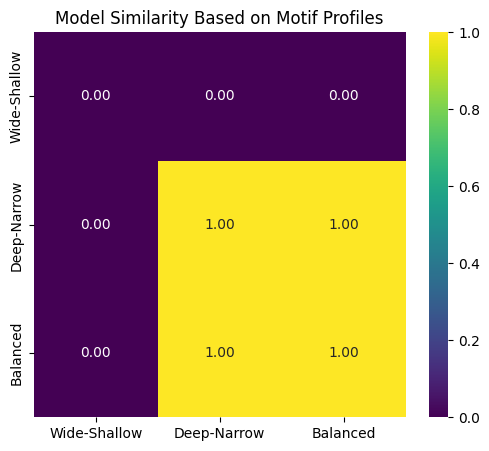

In [33]:
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns

similarity = cosine_similarity(model_vectors)

plt.figure(figsize=(6,5))
sns.heatmap(similarity, annot=True, cmap="viridis",
            xticklabels=model_names, yticklabels=model_names,
            fmt=".2f")
plt.title("Model Similarity Based on Motif Profiles")
plt.show()


### PCA 2D Projection
This creates a 2D “map” of models based on motifs.
Can be used with less components more sensibly.

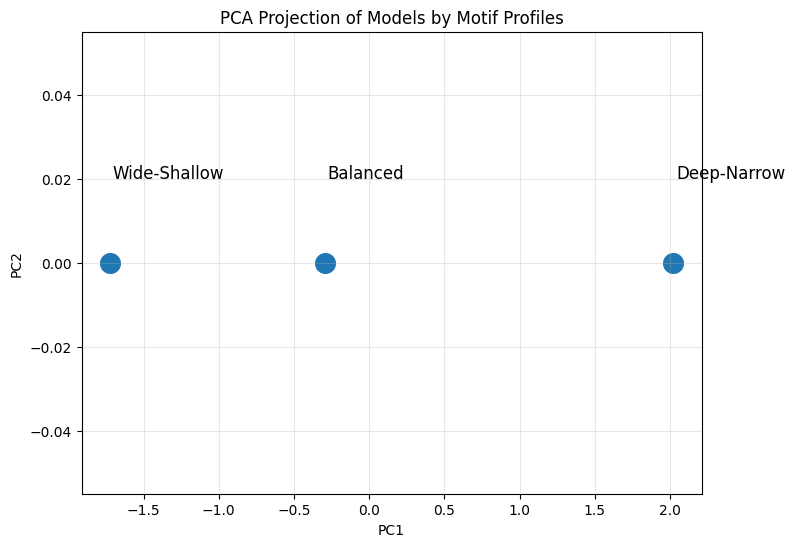

In [35]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
embedding = pca.fit_transform(model_vectors)

plt.figure(figsize=(8,6))
plt.scatter(embedding[:,0], embedding[:,1], s=200)

for i, name in enumerate(model_names):
    plt.text(embedding[i,0]+0.02, embedding[i,1]+0.02, name, fontsize=12)

plt.title("PCA Projection of Models by Motif Profiles")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.3)
plt.show()


### t-SNE Projection (2D)
This creates a 2D “map” of models based on motifs.
Ideally better with more components

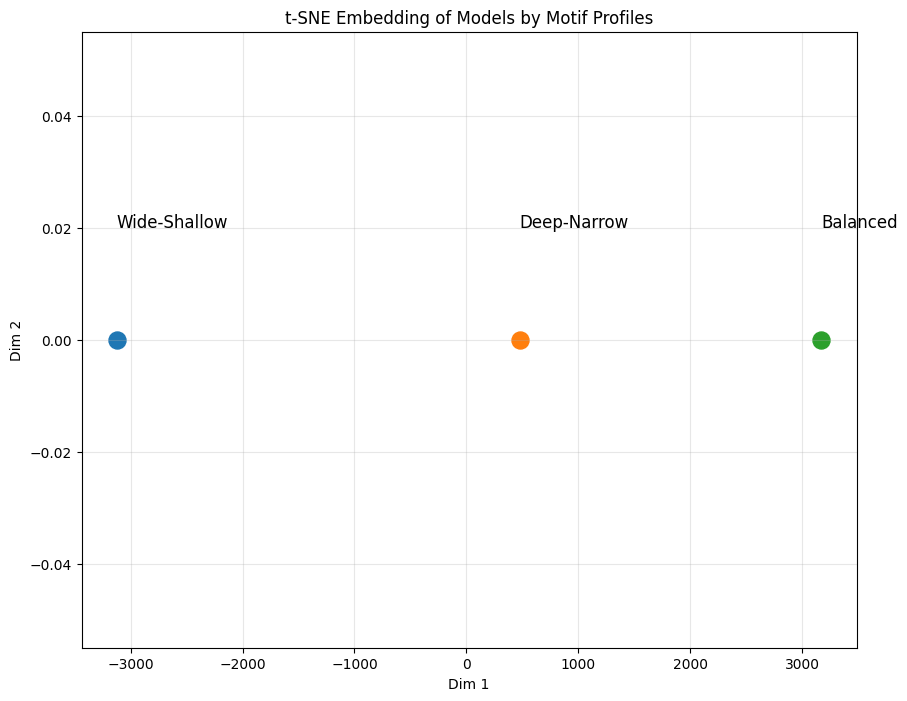

In [34]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(n_components=2, perplexity=1, random_state=42)
embedding = tsne.fit_transform(model_vectors)

plt.figure(figsize=(10, 8))
for i, name in enumerate(model_names):
    plt.scatter(embedding[i, 0], embedding[i, 1], s=150)
    plt.text(embedding[i, 0]+0.02, embedding[i, 1]+0.02, name, fontsize=12)

plt.title("t-SNE Embedding of Models by Motif Profiles")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.grid(alpha=0.3)
plt.show()


---

## Summary & Key Takeaways

### What You Learned

1. **Circuit Comparison**:
   - Multiple metrics: node/edge overlap, structural, functional
   - Different architectures can learn similar circuits
   - Similarity matrices reveal cross-model patterns

2. **Motif Detection**:
   - 6 common computational motifs
   - Statistical significance via randomization tests
   - Z-scores quantify motif enrichment
   - Consensus motifs = universal patterns

3. **Universal Computation**:
   - Some circuit components are task-specific
   - Others are universal (appear across models)
   - Motifs reveal computational primitives

### Key Equations

**Node Overlap**:
$$S_{\text{node}} = \frac{|N_A \cap N_B|}{|N_A \cup N_B|}$$

**Edge Overlap**:
$$S_{\text{edge}} = \frac{|E_A \cap E_B|}{|E_A \cup E_B|}$$

**Motif Z-Score**:
$$Z = \frac{N_{\text{real}} - \langle N_{\text{random}} \rangle}{\sigma_{\text{random}}}$$

### Practical Applications

1. **Transfer Learning**: Identify transferable circuit components
2. **Model Selection**: Choose architectures that learn desired circuits
3. **Debugging**: Compare correct vs buggy model circuits
4. **Interpretability**: Map functionality to motif types
5. **Architecture Design**: Encourage beneficial motif patterns

### Next Steps

- **Notebook 15**: Energy flow through circuit motifs
- **Notebook 16**: Automate circuit analysis pipeline

### References

1. **Milo et al. (2002)**: "Network Motifs: Simple Building Blocks of Complex Networks"
2. **Olah et al. (2020)**: "Zoom In: An Introduction to Circuits"
3. **Fodor & Pylyshyn (1988)**: "Connectionism and cognitive architecture"

---

## Exercises

### Exercise 1: Different Tasks
Train models on different tasks. Do consensus motifs change?

**Starter code**:

In [ ]:
# Exercise 1: Task-dependent motifs
# TODO: Create different task (e.g., XOR vs AND)
# TODO: Extract circuits
# TODO: Compare motifs across tasks

# Your code here:
pass

### Exercise 2: Custom Motifs
Define your own motif patterns and search for them.

**Starter code**:

In [ ]:
# Exercise 2: Custom motif detection
# TODO: Define custom graph pattern
# TODO: Search circuit for pattern
# TODO: Compute significance

# Your code here:
pass

### Exercise 3: Functional Similarity
Measure how similar circuit outputs are (functional similarity).

**Starter code**:

In [ ]:
# Exercise 3: Functional similarity
# TODO: Extract circuit outputs for test data
# TODO: Compute correlation between outputs
# TODO: Compare with structural similarity

# Your code here:
pass

---

**Congratulations!** You've mastered circuit comparison and motif detection. You can now find universal computational patterns across different neural network architectures.

Continue to **Notebook 15: Energy Cascades & Hamiltonian Decomposition** to understand the energy structure of these circuits.